In [4]:
import json, random, csv, time, os, random
import numpy as np
from statistics import mean
from scipy.stats import ttest_rel, ttest_ind
import pandas as pd
from datetime import datetime
from tqdm import tqdm  # for progress bar
import matplotlib.pyplot as plt
from collections import defaultdict

# Load data
with open("../stimuli/coco_all_caption_concereteness_with_lemmatization.json") as f:
    data = json.load(f)

df = pd.DataFrame(columns=['image_id', 'caption', 'concreteness','matching_score'])

for i, img in enumerate(data):
    for c, cap in enumerate(img['caption_concreteness']):
        mean_score = mean([x for x in cap['concreteness'] if not np.isnan(x)])
        df = pd.concat([df, pd.DataFrame({'image_id': img['image'], 'caption': cap['caption'], 'concreteness': mean_score, 'matching_score': cap['matching_score']}, index=[0])], ignore_index=True)

/tmp/ipykernel_3711862/564139904.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame({'image_id': img['image'], 'caption': cap['caption'], 'concreteness': mean_score, 'matching_score': cap['matching_score']}, index=[0])], ignore_index=True)


In [5]:
from scipy.stats import pearsonr

correlation, p = pearsonr(df['concreteness'], df['matching_score'])
print("Pearson correlation between concreteness and matching_score:", correlation, "with p-value:", p)

Pearson correlation between concreteness and matching_score: 0.1422364050608651 with p-value: 3.619433464990563e-113


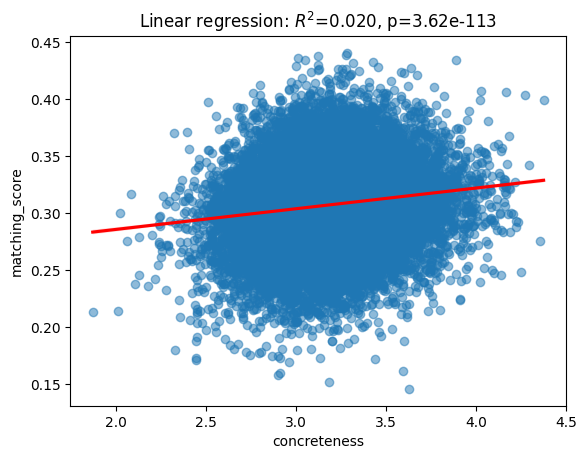

Slope: 0.0181, Intercept: 0.2494, R^2: 0.0202, p-value: 3.6194e-113


In [7]:
from scipy.stats import linregress
import seaborn as sns

slope, intercept, r_value, p_value, std_err = linregress(df['concreteness'], df['matching_score'])
sns.regplot(x=df['concreteness'], y=df['matching_score'], line_kws={"color": "red"}, scatter_kws={"alpha": 0.5})
plt.xlabel("concreteness")
plt.ylabel("matching_score")
plt.title(f"Linear regression: $R^2$={r_value**2:.3f}, p={p_value:.2e}")
plt.show()
print(f"Slope: {slope:.4f}, Intercept: {intercept:.4f}, R^2: {r_value**2:.4f}, p-value: {p_value:.4e}")

